
# **Part 06**

# **Electrode-Driven Coupled Ion Transport and pH Evolution Using FEM**

## **Objective**

Part 6 extends the coupled reaction-diffusion model from Part 5 by adding localized electrode boundary fluxes and computing the resulting pH distribution.

The model consists of:

* an anode on the left boundary producing hydrogen ions;

a cathode on the right boundary that generates hydroxide ions;

* different diffusion coefficients for two ion species;

hydrogen hydroxide neutralization;

* calculation of time-dependent pH;

* numerical verification of the mass balance.

Concentrations are now in moles per liter, domain coordinates in centimeters and time in seconds.

---

### **Reasons for Introducing Electrodes**

Part 5 used initial Gaussian concentration profiles and no continuous ion production. But in an electrochemical process ions are produced continuously at electrode surfaces

The anode produces hydrogen ions and forms an acidic zone:

$$\mathrm{H}^{+}\longleftarrow \mathrm{Anode}$$

The cathode gives hydroxide ions and a basic region:

$$\mathrm{Cathode}\longrightarrow\mathrm{O}^{2-}$$

The ions produced at the electrode diffuse in the domain and react when the distributions of concentration overlap. Therefore, the electrode boundary fluxes are needed for a more realistic simulation of the pH evolution.

---

## **Computational Domain**

The model is solved on the square domain

$$\Omega=[0,1]\times[0,1]\ \mathrm{cm}^{2}.$$

The mesh uses

$$N_x=N_y=12$$

Therefore, the total number of nodes is

$$N_{\mathrm{nodes}}=(N_x+1)(N_y+1)=169$$

and the total number of triangular elements is

$$N_{\mathrm{elements}}=2N_xN_y=288$$

---

## **Coupled Governing Equations**

The hydrogen-ion concentration satisfies

$$\frac{\partial c_{\mathrm{H}^{+}}}{\partial t}=D*_{\mathrm{H}^{+}}\nabla^{2}c_{\mathrm{H}^{+}}-R(c_{\mathrm{H}^{+}},c_*{\mathrm{OH}^{-}})$$

The hydroxide-ion concentration satisfies

$$\frac{\partial c_{\mathrm{OH}^{-}}}{\partial t}=D*_{\mathrm{OH}^{-}}\nabla^{2}c_{\mathrm{OH}^{-}}-R(c_{\mathrm{H}^{+}},c_*{\mathrm{OH}^{-}})$$

Here:

* $c_{\mathrm{H}^{+}}$ is the hydrogen-ion concentration;

* $c_{\mathrm{OH}^{-}}$ is the hydroxide-ion concentration;

* $D_{\mathrm{H}^{+}}$ is the hydrogen diffusion coefficient;

* $D_{\mathrm{OH}^{-}}$ is the hydroxide diffusion coefficient;

* $R$ is the neutralization reaction rate;

* $\nabla^{2}$ is the two-dimensional Laplacian.

---

## **Diffusion Coefficients**

The code uses the representative diffusion coefficients

$$D_{\mathrm{H}^{+}}=9.31\times10^{-5}\ \mathrm{cm}^{2}\mathrm{s}^{-1}$$

and

$$D_{\mathrm{OH}^{-}}=5.27\times10^{-5}\ \mathrm{cm}^{2}\mathrm{s}^{-1}$$

Because

$$D*_{\mathrm{H}^{+}}>D_*{\mathrm{OH}^{-}}$$

hydrogen ions spread faster than hydroxide ions.

---

## **Neutralization Reaction**

The hydrogen and hydroxide ions are consumed through the reaction

$$\mathrm{H}^{+}+\mathrm{OH}^{-}\longrightarrow\mathrm{H}_{2}\mathrm{O}$$

The reaction term is

$$R(c*_{\mathrm{H}^{+}},c_{\mathrm{OH}^{-}})=k\,c_{\mathrm{H}^{+}}c_*{\mathrm{OH}^{-}}$$

The code uses the effective reaction-rate constant

$$k=50\ \mathrm{L\,mol}^{-1}\mathrm{s}^{-1}$$

The reaction rate becomes large where both hydrogen and hydroxide concentrations are present. It becomes small where either concentration approaches zero.

---

## **Initial Conditions**

The domain is initially neutral. Therefore, the initial hydrogen and hydroxide concentrations are

$$c_{\mathrm{H}^{+}}(x,y,0)=10^{-7}\ \mathrm{mol\,L}^{-1}$$

and

$$c_{\mathrm{OH}^{-}}(x,y,0)=10^{-7}\ \mathrm{mol\,L}^{-1}$$

The corresponding initial pH is

$$\mathrm{pH}(x,y,0)=7$$

---

## **Electrode Locations**

The anode is placed on the middle section of the left boundary:

$$x=0,\qquad \frac{1}{3}\leq y\leq\frac{2}{3}$$

The cathode is placed on the middle section of the right boundary:

$$x=1,\qquad \frac{1}{3}\leq y\leq\frac{2}{3}$$

The code identifies all boundary edges whose midpoints lie inside this electrode interval.

For the current mesh, each electrode contains five unique boundary nodes.

---

## **Electrode Boundary Fluxes**

A positive inward hydrogen-ion flux is applied at the anode:

$$D*_{\mathrm{H}^{+}}\frac{\partial c_*{\mathrm{H}^{+}}}{\partial n}=q_{\mathrm{H}^{+}}\qquad\text{on the anode}$$

A positive inward hydroxide-ion flux is applied at the cathode:

$$D*_{\mathrm{OH}^{-}}\frac{\partial c_*{\mathrm{OH}^{-}}}{\partial n}=q_{\mathrm{OH}^{-}}\qquad\text{on the cathode}$$

The code uses

$$q*_{\mathrm{H}^{+}}=q_*{\mathrm{OH}^{-}}=2.0\times10^{-5}$$

These are inward concentration fluxes in the scaled two-dimensional model.

All remaining boundaries have zero flux:

$$-D\frac{\partial c}{\partial n}=0$$

Therefore, ions enter the domain only through the specified electrode surfaces.

---

## **Electrode Boundary-Load Vectors**

For an electrode boundary edge with length $L_e$ and constant inward flux $q$, the local boundary-load vector is

$$\mathbf{f}^{(e)}=\frac{qL_e}{2}\begin{bmatrix}1\\1\end{bmatrix}$$

Therefore, the contribution added to each endpoint of the electrode edge is

$$f_i\mathrel{+}=\frac{qL_e}{2},\qquad f_j\mathrel{+}=\frac{qL_e}{2}$$

The assembled hydrogen boundary vector is denoted by

$$\mathbf{f}_{\mathrm{H}^{+}}$$

and the assembled hydroxide boundary vector is denoted by

$$\mathbf{f}_{\mathrm{OH}^{-}}$$

The total injection rates are calculated using

$$Q*_{\mathrm{H}^{+}}=\mathbf{1}^{T}\mathbf{f}_*{\mathrm{H}^{+}}$$

and

$$Q*_{\mathrm{OH}^{-}}=\mathbf{1}^{T}\mathbf{f}_*{\mathrm{OH}^{-}}$$

---

## **Triangular-Element Area**

For a triangular element with vertices $(x_1,y_1)$, $(x_2,y_2)$, and $(x_3,y_3)$, the signed area is

$$A_e=\frac{1}{2}\left[(x_2-x_1)(y_3-y_1)-(x_3-x_1)(y_2-y_1)\right].$$

The code verifies that

$$A_e>0$$

for every element.

The sum of all element areas must satisfy

$$\sum_e A_e=L_xL_y=1.$$

---

## **Local Mass and Stiffness Matrices**

The local mass matrix is

$$M^{(e)}=\frac{A_e}{12}\begin{bmatrix}2&1&1\1&2&1\1&1&2\end{bmatrix}.$$

The unit-diffusion local stiffness matrix is

$$K_0^{(e)}=A_eGG^{T},$$

where $G$ contains the gradients of the three linear basis functions.

The global matrices are obtained by assembly:

$$M=\sum_eM^{(e)},$$

and

$$K_0=\sum_eK_0^{(e)}.$$

---

## **Lumped Mass Matrix**

A lumped mass matrix is used in Part 6 to improve concentration positivity near the localized electrode sources.

It is constructed by summing each row of the consistent mass matrix:

$$m_i=\sum*_jM_*{ij}.$$

The lumped mass matrix is

$$M_L=\operatorname{diag}(m_1,m_2,\ldots,m_N).$$

The code verifies that every diagonal value satisfies

$$m_i>0.$$

The lumped matrix is diagonal and makes the reaction and boundary-source calculations simpler and more stable.

---

## **Semi-Discrete FEM System**

Let $\mathbf{h}(t)$ represent the nodal hydrogen concentrations and $\mathbf{o}(t)$ represent the nodal hydroxide concentrations.

The hydrogen FEM equation is

$$M*_L\frac{d\mathbf{h}}{dt}+D_{\mathrm{H}^{+}}K_0\mathbf{h}+M_L\mathbf{r}(\mathbf{h},\mathbf{o})=\mathbf{f}_*{\mathrm{H}^{+}}.$$

The hydroxide FEM equation is

$$M*_L\frac{d\mathbf{o}}{dt}+D_{\mathrm{OH}^{-}}K_0\mathbf{o}+M_L\mathbf{r}(\mathbf{h},\mathbf{o})=\mathbf{f}_*{\mathrm{OH}^{-}}.$$

The nodal reaction vector is

$$\mathbf{r}(\mathbf{h},\mathbf{o})=k(\mathbf{h}\odot\mathbf{o}),$$

where $\odot$ denotes component-wise multiplication.

---

##  **IMEX Euler Time Integration**

The diffusion terms are treated implicitly, while the nonlinear reaction term is treated explicitly.

The hydrogen update equation is

$$\left(M*_L+\Delta tD_{\mathrm{H}^{+}}K_0\right)\mathbf{h}^{n+1}=M_L\mathbf{h}^{n}-\Delta tM_L\mathbf{r}^{n}+\Delta t\mathbf{f}_*{\mathrm{H}^{+}}.$$

The hydroxide update equation is

$$\left(M*_L+\Delta tD_{\mathrm{OH}^{-}}K_0\right)\mathbf{o}^{n+1}=M_L\mathbf{o}^{n}-\Delta tM_L\mathbf{r}^{n}+\Delta t\mathbf{f}_*{\mathrm{OH}^{-}}.$$

The reaction vector at the current time level is

$$\mathbf{r}^{n}=k(\mathbf{h}^{n}\odot\mathbf{o}^{n}).$$

The system matrices are

$$A_{\mathrm{H}^{+}}=M*_L+\Delta tD_*{\mathrm{H}^{+}}K_0,$$

and

$$A_{\mathrm{OH}^{-}}=M*_L+\Delta tD_*{\mathrm{OH}^{-}}K_0.$$

Both matrices are factorized once using LU factorization and reused during time integration.

---

## **Time Parameters**

The simulation begins at

$$t_0=0\ \mathrm{s}$$

and ends at

$$T=600\ \mathrm{s}.$$

The time-step size is

$$\Delta t=0.25\ \mathrm{s}.$$

Therefore, the number of time steps is

$$N_t=\frac{T-t_0}{\Delta t}=2400.$$

The concentrations and pH are stored at

$$t=0,\ 100,\ 300,\ 600\ \mathrm{s}.$$

---

## **Calculation of pH**

The pH is calculated from the hydrogen-ion concentration:

$$\mathrm{pH}=-\log*_{10}(c_*{\mathrm{H}^{+}}).$$

A lower concentration limit is introduced before applying the logarithm:

$$c*_{\mathrm{safe}}=\max(c_*{\mathrm{H}^{+}},10^{-14}).$$

Therefore, the numerical pH calculation is

$$\mathrm{pH}=-\log*_{10}(c_*{\mathrm{safe}}).$$

This lower limit prevents the logarithm of zero and avoids undefined numerical values.

A lower pH represents an acidic region, while a higher pH represents a basic region.

---

## **Integrated Ion Concentrations**

The integrated hydrogen concentration is

$$C_{\mathrm{H}^{+}}^{n}=\mathbf{1}^{T}M_L\mathbf{h}^{n}.$$

The integrated hydroxide concentration is

$$C_{\mathrm{OH}^{-}}^{n}=\mathbf{1}^{T}M_L\mathbf{o}^{n}.$$

These quantities change because ions are continuously injected at the electrodes and consumed by the neutralization reaction.

---

## **Cumulative and Integrated Reaction**

The integrated reaction rate at time level $n$ is

$$R_{\mathrm{total}}^{n}=\mathbf{1}^{T}M_L\mathbf{r}^{n}.$$

The cumulative amount consumed by the reaction is approximated by

$$S^{n}=\sum*_{m=0}^{n-1}\Delta t,R_*{\mathrm{total}}^{m}.$$

The same cumulative reaction amount is removed from hydrogen and hydroxide concentrations.

---

## **Ion Mass-Balance Verification**

The total injected hydrogen concentration at time $t_n$ is

$$I_{\mathrm{H}^{+}}^{n}=t*_nQ_*{\mathrm{H}^{+}}.$$

The total injected hydroxide concentration is

$$I_{\mathrm{OH}^{-}}^{n}=t*_nQ_*{\mathrm{OH}^{-}}.$$

The hydrogen mass-balance residual is

$$E*_{\mathrm{H}^{+}}^{n}=C_{\mathrm{H}^{+}}^{n}-C_{\mathrm{H}^{+}}^{0}-I_*{\mathrm{H}^{+}}^{n}+S^{n}.$$

The hydroxide mass-balance residual is

$$E*_{\mathrm{OH}^{-}}^{n}=C_{\mathrm{OH}^{-}}^{n}-C_{\mathrm{OH}^{-}}^{0}-I_*{\mathrm{OH}^{-}}^{n}+S^{n}.$$

For a correctly assembled numerical model,

$$E_{\mathrm{H}^{+}}^{n}\approx0,$$and

$$E_{\mathrm{OH}^{-}}^{n}\approx0.$$

The maximum absolute errors are calculated over all time levels.




---

## **Numerical Verification Checks**

The code tests the following properties:

1. Total mesh area = area of the domain.

2. All triangular elements have positive area.

3. The mass matrix of the world is symmetric.

4. The global stiffness matrix is symmetrical.

5. The lumped mass matrix is diagonal with positive diagonal entries.

6. The sets of electrode nodes are non-empty.

7. The injection rates of both electrodes are positive.

8. All concentrations and pH values are finite.

9. No significant concentration of negative ions is developed.

10. The hydrogen mass-balance error is < $10^{-10}$.

11. The mass-balance error of hydroxide is less than $10^{-10}$.

12. Final minimum pH is lower than the initial pH.

13. The final maximum pH is higher than the first pH.

The concentration check is

$$\min(c*_{\mathrm{H}^{+}},c_*{\mathrm{OH}^{-}})\geq-10^{-12}$$

The small negative tolerance allows for floating-point round-off errors.

---

## **Visualization**

The code generates three figures.

### **Hydrogen and Hydroxide Evolution**

Hydrogen and hydroxide concentrations are plotted at

$$t=0,\ 100,\ 300,\ 600\ \mathrm{s}$$

The hydrogen plots show ion production and diffusion from the anode. The hydroxide plots show production and diffusion from the cathode.

### **pH Changes**

Figure 2 shows the pH distribution for the same four timings.

The plots indicate:

* formation of an acid zone near the anode;

* a major region of development near the cathode;

the territorial expansion of the two regions;

* a region of transition between the two electrodes.

### **Numerical Diagnostic Graphs**

The diagnostic figure displays:

* minimum and maximum pH;

* integrated hydrogen and hydroxide concentrations;

* hydrogen and hydroxide mass-balance errors;

* integrated neutralization rate.

---

## **Expected Physical Behaviour**

At the start of the simulation, the complete domain has pH 7.

As time increases:

* Hydrogen ions are produced at the left anode;

* The pH near the anode decreases;

* Hydroxide ions are produced at the right cathode;

* The pH near the cathode increases;

* Both ionic species diffuse towards the centre;

* Neutralization occurs where the two species overlap;

* Acidic and basic regions expand through the domain;

* The numerical mass-balance residuals remain close to zero.

---

## **Scope and Limitations**

Part 6 introduces physical concentration values, localized electrode sources, coupled neutralization, and pH evolution. However, it remains a simplified two-dimensional mathematical model.

The model does not yet include:

* electric potential;

* electric-field-driven ionic migration;

* tissue-specific material properties;

* multiple biological subdomains;

* buffer reactions;

* realistic electrode kinetics;

* experimentally calibrated parameters.

Therefore, the results shows the numerical behaviour of the FEM model and should not be interpreted as clinical predictions.


Number of nodes: 169
Number of elements: 288
Hydrogen diffusion coefficient: 9.31e-05 cm^2/s
Hydroxide diffusion coefficient: 5.27e-05 cm^2/s
Reaction-rate constant: 50.0
Initial neutral concentration: 1e-07 mol/L
Global FEM matrices assembled successfully.
Mass matrix shape: (169, 169)
Stiffness matrix shape: (169, 169)
Total mesh area: 1.0
Number of anode nodes: 5
Number of cathode nodes: 5
Hydrogen injection rate: 6.666666666666667e-06
Hydroxide injection rate: 6.666666666666667e-06
Initial time: 0.0
Final time: 600.0
Time-step size: 0.25
Number of time steps: 2400
Electrode-driven ion-transport and pH simulation completed.
Initial total hydrogen concentration: 1.0000000000000002e-07
Final total hydrogen concentration: 0.0038102712270212486
Initial total hydroxide concentration: 1.0000000000000002e-07
Final total hydroxide concentration: 0.0038102712270211584
Initial minimum pH: 7.0
Final minimum pH: 1.4050380252067067
Initial maximum pH: 7.0
Final maximum pH: 12.474625052003988
Min

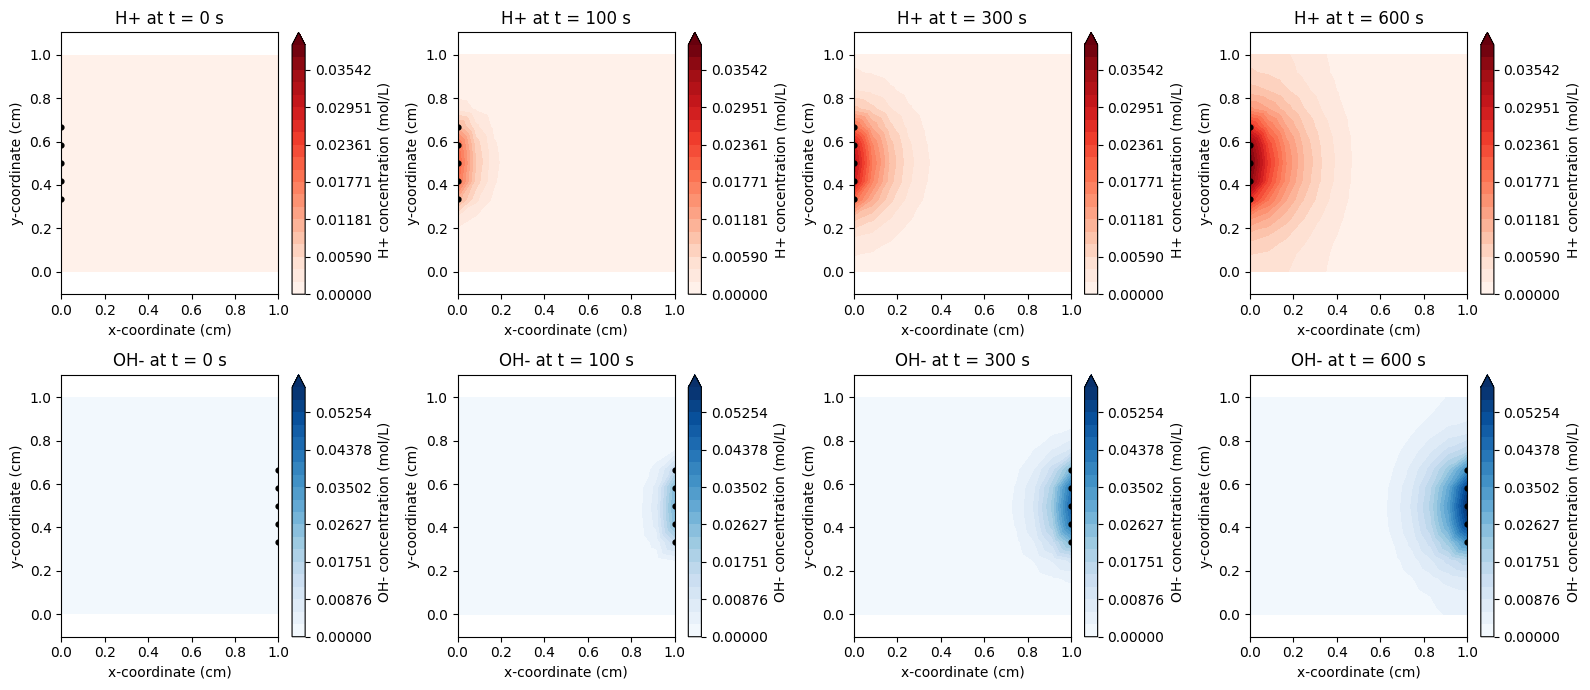

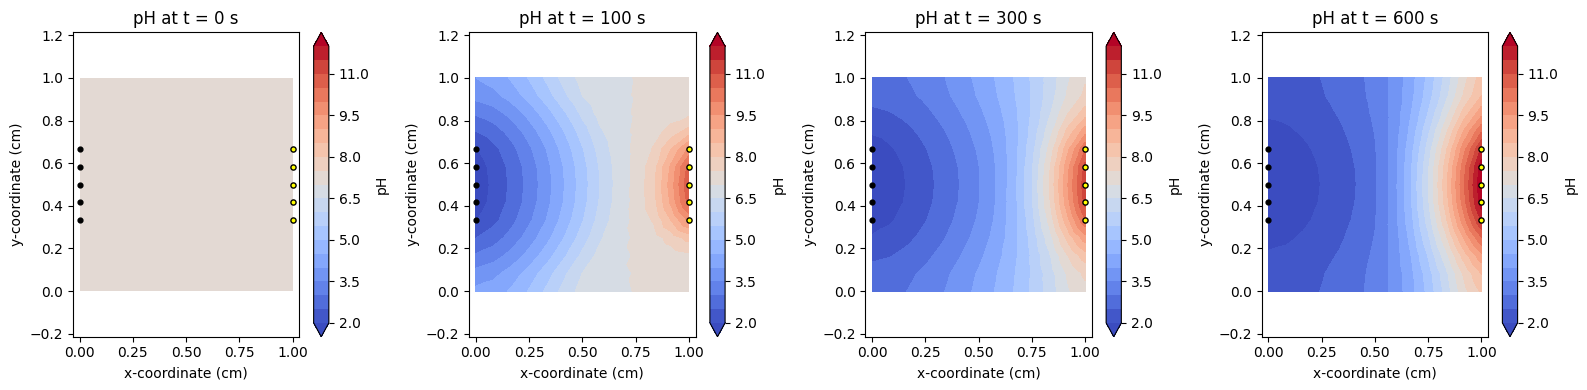

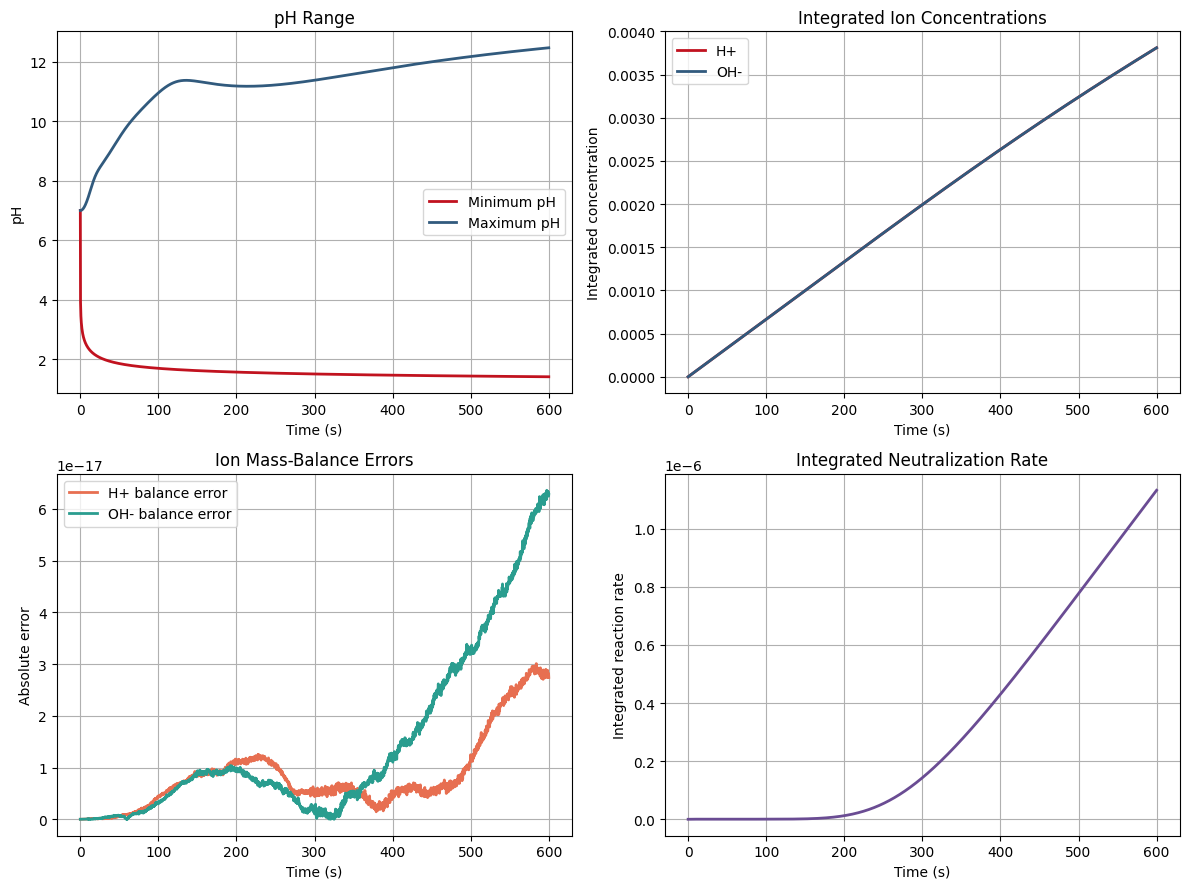

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu_factor, lu_solve
np.set_printoptions(precision=8,suppress=True)
Lx = 1.0
Ly = 1.0
Nx = 12
Ny = 12
x = np.linspace(0.0,Lx,Nx + 1)
y = np.linspace(0.0,Ly,Ny + 1)
X, Y = np.meshgrid(x,y,indexing="xy")
nodes = np.column_stack((X.ravel(),Y.ravel()))
elements = []
for j in range(Ny):
    for i in range(Nx):
        n1 = j * (Nx + 1) + i
        n2 = n1 + 1
        n3 = n1 + (Nx + 1)
        n4 = n3 + 1
        elements.append([n1,n2,n4])
        elements.append([n1,n4,n3])
elements = np.asarray(elements,dtype=int)
number_of_nodes = len(nodes)
number_of_elements = len(elements)
# Model parameters
D_hydrogen = 9.31e-5
D_hydroxide = 5.27e-5
reaction_rate_constant = 50.0
initial_neutral_concentration = 1.0e-7
hydrogen_boundary_flux = 2.0e-5
hydroxide_boundary_flux = 2.0e-5
print("Number of nodes:",number_of_nodes)
print("Number of elements:",number_of_elements)
print("Hydrogen diffusion coefficient:",D_hydrogen,"cm^2/s")
print("Hydroxide diffusion coefficient:",D_hydroxide,"cm^2/s")
print("Reaction-rate constant:",reaction_rate_constant)
print("Initial neutral concentration:",initial_neutral_concentration,"mol/L")
# Initialize FEM matrices
global_mass = np.zeros((number_of_nodes,number_of_nodes))
global_stiffness = np.zeros((number_of_nodes,number_of_nodes))
element_areas = np.zeros(number_of_elements)
# Assemble FEM matrices
for element_index in range(number_of_elements):
    element = elements[element_index]
    coordinates = nodes[element]
    x1, y1 = coordinates[0]
    x2, y2 = coordinates[1]
    x3, y3 = coordinates[2]
    area = 0.5 * ((x2-x1)*(y3-y1)-(x3-x1)*(y2-y1))
    if area <= 0.0:
        raise ValueError("A reversed or degenerate element was found.")
    element_areas[element_index] = area
    b_coefficients = np.array([y2-y3, y3-y1, y1-y2])
    c_coefficients = np.array([x3-x2, x1-x3, x2-x1])
    basis_gradients = np.column_stack((b_coefficients,c_coefficients)) / (2.0*area)
    local_mass = (area/12.0) * np.array([[2.0,1.0,1.0], [1.0,2.0,1.0], [1.0,1.0,2.0]])
    local_stiffness = area * (basis_gradients @ basis_gradients.T)
    for local_i in range(3):
        global_i = element[local_i]
        for local_j in range(3):
            global_j = element[local_j]
            global_mass[global_i,global_j] += local_mass[local_i,local_j]
            global_stiffness[global_i,global_j] += local_stiffness[local_i,local_j]
# Construct lumped mass matrix
lumped_mass_values = np.sum(global_mass,axis=1)
lumped_mass = np.diag(lumped_mass_values)
print("Global FEM matrices assembled successfully.")
print("Mass matrix shape:",global_mass.shape)
print("Stiffness matrix shape:",global_stiffness.shape)
print("Total mesh area:",element_areas.sum())
# Verify mesh and matrices
assert np.isclose(element_areas.sum(),Lx*Ly), "The mesh area is incorrect."
assert np.all(element_areas > 0.0), "A non-positive element area was found."
assert np.max(np.abs(global_mass-global_mass.T)) < 1.0e-12, "The mass matrix is not symmetric."
assert np.max(np.abs(global_stiffness-global_stiffness.T)) < 1.0e-12, "The stiffness matrix is not symmetric."
assert np.all(lumped_mass_values > 0.0), "The lumped mass matrix has a non-positive entry."
# Electrode positions
electrode_y_minimum = 1.0/3.0
electrode_y_maximum = 2.0/3.0
hydrogen_flux_vector = np.zeros(number_of_nodes)
hydroxide_flux_vector = np.zeros(number_of_nodes)
anode_nodes = []
cathode_nodes = []
# Assemble electrode boundary contributions
for j in range(Ny):
    y_bottom = y[j]
    y_top = y[j + 1]
    edge_midpoint = 0.5 * (y_bottom+y_top)
    edge_length = y_top-y_bottom
    if electrode_y_minimum <= edge_midpoint <= electrode_y_maximum:
        left_bottom = j * (Nx + 1)
        left_top = (j + 1) * (Nx + 1)
        right_bottom = j * (Nx + 1) + Nx
        right_top = (j + 1) * (Nx + 1) + Nx
        hydrogen_flux_vector[left_bottom] += hydrogen_boundary_flux * edge_length/2.0
        hydrogen_flux_vector[left_top] += hydrogen_boundary_flux * edge_length/2.0
        hydroxide_flux_vector[right_bottom] += hydroxide_boundary_flux * edge_length/2.0
        hydroxide_flux_vector[right_top] += hydroxide_boundary_flux * edge_length/2.0
        anode_nodes.extend([left_bottom,left_top])
        cathode_nodes.extend([right_bottom,right_top])
anode_nodes = np.unique(np.asarray(anode_nodes,dtype=int))
cathode_nodes = np.unique(np.asarray(cathode_nodes,dtype=int))
hydrogen_injection_rate = np.sum(hydrogen_flux_vector)
hydroxide_injection_rate = np.sum(hydroxide_flux_vector)
print("Number of anode nodes:",len(anode_nodes))
print("Number of cathode nodes:",len(cathode_nodes))
print("Hydrogen injection rate:",hydrogen_injection_rate)
print("Hydroxide injection rate:",hydroxide_injection_rate)
assert len(anode_nodes) > 0, "No anode nodes were found."
assert len(cathode_nodes) > 0, "No cathode nodes were found."
assert hydrogen_injection_rate > 0.0, "The hydrogen boundary source is zero."
assert hydroxide_injection_rate > 0.0, "The hydroxide boundary source is zero."
# Time parameters
initial_time = 0.0
final_time = 600.0
time_step = 0.25
number_of_time_steps = int(round((final_time-initial_time)/time_step))
time_values = np.linspace(initial_time,final_time,number_of_time_steps + 1)
print("Initial time:",initial_time)
print("Final time:",final_time)
print("Time-step size:",time_step)
print("Number of time steps:",number_of_time_steps)
# Construct and factorize system matrices
hydrogen_system_matrix = lumped_mass + time_step*D_hydrogen*global_stiffness
hydroxide_system_matrix = lumped_mass + time_step*D_hydroxide*global_stiffness
hydrogen_lu, hydrogen_pivots = lu_factor(hydrogen_system_matrix)
hydroxide_lu, hydroxide_pivots = lu_factor(hydroxide_system_matrix)
# Initial neutral concentrations
hydrogen_concentration = initial_neutral_concentration * np.ones(number_of_nodes)
hydroxide_concentration = initial_neutral_concentration * np.ones(number_of_nodes)

def calculate_pH(hydrogen_values):
    safe_hydrogen = np.maximum(hydrogen_values,1.0e-14)
    return -np.log10(safe_hydrogen)

pH_values = calculate_pH(hydrogen_concentration)
# Diagnostic arrays
total_hydrogen = np.zeros(number_of_time_steps + 1)
total_hydroxide = np.zeros(number_of_time_steps + 1)
minimum_pH = np.zeros(number_of_time_steps + 1)
maximum_pH = np.zeros(number_of_time_steps + 1)
integrated_reaction_rate = np.zeros(number_of_time_steps + 1)
cumulative_reaction = np.zeros(number_of_time_steps + 1)
hydrogen_balance_error = np.zeros(number_of_time_steps + 1)
hydroxide_balance_error = np.zeros(number_of_time_steps + 1)
constant_vector = np.ones(number_of_nodes)
initial_total_hydrogen = constant_vector @ lumped_mass @ hydrogen_concentration
initial_total_hydroxide = constant_vector @ lumped_mass @ hydroxide_concentration

def store_diagnostics(step):
    reaction_term = reaction_rate_constant * hydrogen_concentration * hydroxide_concentration
    total_hydrogen[step] = constant_vector @ lumped_mass @ hydrogen_concentration
    total_hydroxide[step] = constant_vector @ lumped_mass @ hydroxide_concentration
    minimum_pH[step] = np.min(pH_values)
    maximum_pH[step] = np.max(pH_values)
    integrated_reaction_rate[step] = constant_vector @ lumped_mass @ reaction_term
    injected_hydrogen = time_values[step] * hydrogen_injection_rate
    injected_hydroxide = time_values[step] * hydroxide_injection_rate
    hydrogen_balance_error[step] = total_hydrogen[step]-initial_total_hydrogen-injected_hydrogen+cumulative_reaction[step]
    hydroxide_balance_error[step] = total_hydroxide[step]-initial_total_hydroxide-injected_hydroxide+cumulative_reaction[step]
store_diagnostics(0)
# Selected visualization times
selected_times = [0.0,100.0,300.0,600.0]
selected_steps = [int(round(time/time_step)) for time in selected_times]
hydrogen_snapshots = {0: hydrogen_concentration.copy()}
hydroxide_snapshots = {0: hydroxide_concentration.copy()}
pH_snapshots = {0: pH_values.copy()}

# IMEX Euler time stepping
for time_step_index in range(1,number_of_time_steps + 1):
    reaction_term = reaction_rate_constant * hydrogen_concentration * hydroxide_concentration
    current_reaction_integral = constant_vector @ lumped_mass @ reaction_term
    hydrogen_right_hand_side = lumped_mass @ hydrogen_concentration-time_step*(lumped_mass @ reaction_term)+time_step*hydrogen_flux_vector
    hydroxide_right_hand_side = lumped_mass @ hydroxide_concentration-time_step*(lumped_mass @ reaction_term)+time_step*hydroxide_flux_vector
    hydrogen_concentration = lu_solve((hydrogen_lu,hydrogen_pivots),hydrogen_right_hand_side)
    hydroxide_concentration = lu_solve((hydroxide_lu,hydroxide_pivots),hydroxide_right_hand_side)
    pH_values = calculate_pH(hydrogen_concentration)
    cumulative_reaction[time_step_index] = cumulative_reaction[time_step_index-1]+time_step*current_reaction_integral
    store_diagnostics(time_step_index)
    if time_step_index in selected_steps:
        hydrogen_snapshots[time_step_index] = hydrogen_concentration.copy()
        hydroxide_snapshots[time_step_index] = hydroxide_concentration.copy()
        pH_snapshots[time_step_index] = pH_values.copy()
print("Electrode-driven ion-transport and pH simulation completed.")
# Numerical verification
all_values_are_finite = np.all(np.isfinite(hydrogen_concentration)) and np.all(np.isfinite(hydroxide_concentration)) and np.all(np.isfinite(pH_values))
minimum_ion_concentration = min(np.min(hydrogen_concentration),np.min(hydroxide_concentration))
maximum_hydrogen_balance_error = np.max(np.abs(hydrogen_balance_error))
maximum_hydroxide_balance_error = np.max(np.abs(hydroxide_balance_error))
print("Initial total hydrogen concentration:",total_hydrogen[0])
print("Final total hydrogen concentration:",total_hydrogen[-1])
print("Initial total hydroxide concentration:",total_hydroxide[0])
print("Final total hydroxide concentration:",total_hydroxide[-1])
print("Initial minimum pH:",minimum_pH[0])
print("Final minimum pH:",minimum_pH[-1])
print("Initial maximum pH:",maximum_pH[0])
print("Final maximum pH:",maximum_pH[-1])
print("Minimum final ion concentration:",minimum_ion_concentration)
print("Maximum hydrogen balance error:",maximum_hydrogen_balance_error)
print("Maximum hydroxide balance error:",maximum_hydroxide_balance_error)
assert all_values_are_finite, "The solution contains NaN or infinite values."
assert minimum_ion_concentration >= -1.0e-12, "A negative ion concentration was produced."
assert maximum_hydrogen_balance_error < 1.0e-10, "The hydrogen mass balance failed."
assert maximum_hydroxide_balance_error < 1.0e-10, "The hydroxide mass balance failed."
assert minimum_pH[-1] < minimum_pH[0], "An acidic region was not produced."
assert maximum_pH[-1] > maximum_pH[0], "A basic region was not produced."
print("All electrode-flux and pH checks passed successfully.")
# Common colour levels
hydrogen_maximum = max(np.max(hydrogen_snapshots[step]) for step in selected_steps)
hydroxide_maximum = max(np.max(hydroxide_snapshots[step]) for step in selected_steps)
hydrogen_levels = np.linspace(0.0,hydrogen_maximum,21)
hydroxide_levels = np.linspace(0.0,hydroxide_maximum,21)
pH_levels = np.linspace(2.0,12.0,21)
# Plot ion-concentration evolution
plt.figure(figsize=(16,7))
for plot_index, step in enumerate(selected_steps):
    plt.subplot(2,4,plot_index + 1)
    hydrogen_plot = plt.tricontourf(nodes[:, 0],nodes[:, 1],elements,hydrogen_snapshots[step],levels=hydrogen_levels,cmap="Reds",extend="max")
    plt.colorbar(hydrogen_plot,label="H+ concentration (mol/L)")
    plt.scatter(nodes[anode_nodes,0],nodes[anode_nodes,1],color="black",s=12,label="Anode")
    plt.title(f"H+ at t = {time_values[step]:.0f} s")
    plt.xlabel("x-coordinate (cm)")
    plt.ylabel("y-coordinate (cm)")
    plt.axis("equal")
    plt.subplot(2,4,plot_index + 5)
    hydroxide_plot = plt.tricontourf(nodes[:, 0],nodes[:, 1],elements,hydroxide_snapshots[step],levels=hydroxide_levels,cmap="Blues",extend="max")
    plt.colorbar(hydroxide_plot,label="OH- concentration (mol/L)")
    plt.scatter(nodes[cathode_nodes,0],nodes[cathode_nodes,1],color="black",s=12,label="Cathode")
    plt.title(f"OH- at t = {time_values[step]:.0f} s")
    plt.xlabel("x-coordinate (cm)")
    plt.ylabel("y-coordinate (cm)")
    plt.axis("equal")
plt.tight_layout()
plt.savefig("electrode_driven_ion_evolution.png",dpi=300,bbox_inches="tight")
plt.show()
# Plot pH evolution
plt.figure(figsize=(16,4))
for plot_index, step in enumerate(selected_steps,start=1):
    plt.subplot(1,4,plot_index)
    pH_plot = plt.tricontourf(nodes[:, 0],nodes[:, 1],elements,pH_snapshots[step],levels=pH_levels,cmap="coolwarm",extend="both")
    plt.colorbar(pH_plot,label="pH")
    plt.scatter(nodes[anode_nodes,0],nodes[anode_nodes,1],color="black",s=12)
    plt.scatter(nodes[cathode_nodes,0],nodes[cathode_nodes,1],color="yellow",edgecolor="black",s=14)
    plt.title(f"pH at t = {time_values[step]:.0f} s")
    plt.xlabel("x-coordinate (cm)")
    plt.ylabel("y-coordinate (cm)")
    plt.axis("equal")
plt.tight_layout()
plt.savefig("pH_evolution_with_electrodes.png",dpi=300,bbox_inches="tight")
plt.show()
# Plot numerical diagnostics
plt.figure(figsize=(12,9))
plt.subplot(2,2,1)
plt.plot(time_values,minimum_pH,color="#C1121F",linewidth=2,label="Minimum pH")
plt.plot(time_values,maximum_pH,color="#315A7D",linewidth=2,label="Maximum pH")
plt.title("pH Range")
plt.xlabel("Time (s)")
plt.ylabel("pH")
plt.grid(True)
plt.legend()
plt.subplot(2,2,2)
plt.plot(time_values,total_hydrogen,color="#C1121F",linewidth=2,label="H+")
plt.plot(time_values,total_hydroxide,color="#315A7D",linewidth=2,label="OH-")
plt.title("Integrated Ion Concentrations")
plt.xlabel("Time (s)")
plt.ylabel("Integrated concentration")
plt.grid(True)
plt.legend()
plt.subplot(2,2,3)
plt.plot(time_values,np.abs(hydrogen_balance_error),color="#E76F51",linewidth=2,label="H+ balance error")
plt.plot(time_values,np.abs(hydroxide_balance_error),color="#2A9D8F",linewidth=2,label="OH- balance error")
plt.title("Ion Mass-Balance Errors")
plt.xlabel("Time (s)")
plt.ylabel("Absolute error")
plt.grid(True)
plt.legend()
plt.subplot(2,2,4)
plt.plot(time_values,integrated_reaction_rate,color="#6A4C93",linewidth=2)
plt.title("Integrated Neutralization Rate")
plt.xlabel("Time (s)")
plt.ylabel("Integrated reaction rate")
plt.grid(True)
plt.tight_layout()
plt.savefig("electrode_pH_verification_graphs.png",dpi=300,bbox_inches="tight")
plt.show()

## **Results, Interpretation, and Conclusion**

The electrode-driven coupled ion-transport model was successfully solved on a mesh containing 169 nodes and 288 triangular elements. The total mesh area was equal to 1.0, and the global mass and stiffness matrices had the correct dimensions of 169 × 169. Five boundary nodes were identified for each electrode.

The anode supplied hydrogen ions from the left boundary, while the cathode supplied hydroxide ions from the right boundary. Both electrodes had an equal integrated injection rate of approximately 6.67 × 10⁻⁶. The concentration plots show that hydrogen ions spread from the anode into the domain, while hydroxide ions spread from the cathode. Because hydrogen ions have a larger diffusion coefficient, their concentration distribution spreads more widely. Hydroxide ions diffuse more slowly and remain more concentrated near the cathode.

The hydrogen concentration (integrated) went from 1.00 x 10-7 to 0.00381027$. In the same way, the total hydroxide concentration went up from 1.00 × 10⁻⁷ to 0.00381027. The final integrated values are basically the same as the two electrodes inject equal rates and the neutralization reaction consumes equal amounts of both species.

The ion-concentration plots show that the acidic and basic regions expand with time. When the hydrogen and hydroxide distributions begin to overlap, the neutralization reaction becomes stronger. This behavior is also shown by the integrated neutralization-rate graph, which increases as the two ionic fronts move towards each other.

Initially, the complete domain had a **neutral pH of 7**. After** 600 seconds**, the minimum pH decreased to approximately 1.405 near the anode, confirming the formation of a strongly acidic region. The maximum pH increased to approximately 12.475 near the cathode, confirming the formation of a strongly basic region. The pH plots also show a transition region between the acidic and basic parts of the domain.

The minimum final ion concentration was approximately 8.82 × 10⁻¹⁶ and remained non-negative. Therefore, the mass-lumped FEM formulation successfully prevented significant negative concentration values near the localized electrode sources.

The maximum hydrogen mass-balance error was approximately 3.01 × 10⁻¹⁷, while the maximum hydroxide mass-balance error was approximately 6.36 × 10⁻¹⁷. These errors are close to machine precision and confirm that electrode injection, diffusion, and neutralization were assembled consistently.

All numerical verification checks passed successfully. Therefore, Part 6 successfully extended the coupled reaction–diffusion solver by including localized electrode boundary fluxes, physical ion concentrations, and time-dependent pH evolution.

The **model** shows the expected numerical behavior: acidic conditions develop near the anode, basic conditions develop near the cathode, ions diffuse through the domain, and neutralization occurs where the two concentration fields overlap. This verified framework provides a strong foundation for introducing electric potential, ionic migration, parameter studies, and more realistic electrochemical conditions in the next stage.
